## LOAD AND SAVE CONNECTOM MATRICES FOR HUMAN AND RAT WITH SIMILAR NUMBER OF NODES

This notebook loads the connectome for the human and the rat STRUCTURAL microcircuits. This means that synapses are placed at ALL touch locations. 

It is based on the following notebook (https://bbpgitlab.epfl.ch/conn/papers/sscx_and_em/-/blob/main/notebooks/microns/Schneider-Mizell/100%20um%20microns%20struc.ipynb?ref_type=heads)

We will load connectomes of different radius for the rat and the human, so we could obtain similar number of neurons (1000 approx).

#### WARNING!!

This notebook can be run as it is for connectivity matrices with no more than 5000 nodes approximately.
If you want to build bigger matrices, I recommend to launch the python scripts: GetConnMatBIG_Rat.py and GetConnMatBIG_Human.py

However, you can use the notebook to define the flatmap ranges.


In [1]:
import numpy, pandas, conntility
import numpy as np
import bluepysnap as snap
import voxcell
import json
from matplotlib import pyplot as plt
import h5py
import tqdm
import LoadConnMat as lcm # package with useful functions to load connectivity matrices for this case.

## Let's work on the rat first

#### 1) load the circuit and the positions and orientations of cells in the respective flatmaps

Load the connectivity and invoque the flat mapping mannually, considering different faltmap ranges for each circuit so we get 5000 nodes approximately using __load_conn_node__ 

In [2]:
# RAT
fn_rat = "/gpfs/bbp.cscs.ch/project/proj83/jira-tickets/NSETM-1948-extract-hex-O1/data/S1_data/circuit_config.json"
rat_atlas_dir = "/gpfs/bbp.cscs.ch/project/proj83/jira-tickets/NSETM-1948-extract-hex-O1/data/O1_data_physiology/atlas/"

fm_rat = voxcell.VoxelData.load_nrrd(rat_atlas_dir + "flatmap.nrrd")
orient_rat = voxcell.VoxelData.load_nrrd(rat_atlas_dir + "orientation.nrrd")
circ_rat = snap.Circuit(fn_rat)

syn = 'EXC'
layers_rat = ['2','3']
#range_x_rat = [1000,1623] #square to match same num nodes (cells) as in human (aprox 20000)
#range_y_rat = [1000,1623]
range_x_rat = [1000,1135] #square to match same num nodes (cells) as in human (aprox 1000)
range_y_rat = [1000,1135]
pixel_sz_rat = 34.0
node_pop_rat = 'S1nonbarrel_neurons'

nrn_rat = lcm.load_conn_node(circ_rat, layers_rat, syn, range_x_rat, range_y_rat, fm_rat, orient_rat, pixel_sz_rat, node_population_name=node_pop_rat)
nrn_rat

/gpfs/bbp.cscs.ch/home/barros/ConnectomeUtilities/conntility/flatmapping/_supersample_utility.py:137: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  res = Rotation.align_vectors(vtgt, vv)


Rotation errors: min: 0.0, median: 0.09387602600937471, mean: 0.136282418448154, std: 0.15664142313801505, max: 2.0


,node_ids,etype,layer,morphology,mtype,synapse_class,x,y,z,ss_flat_x,depth,ss_flat_y
9259,9259,cADpyr,3,dend-C170797A-P2_axon-sm110128a1-2_INT_idA_-_S...,L3_TPC:A,EXC,4493.716872,-2849.608773,-2725.415093,1050.918638,514.246435,1010.970431
9506,9506,cADpyr,3,dend-mtC221001A_idA_axon-rat_20150323_E2_LH3_c...,L3_TPC:A,EXC,4632.106817,-2799.169324,-2561.053188,1084.366140,397.207262,1133.953656
9688,9688,cADpyr,3,dend-rat_20160907_LH2_cell1_axon-rat_20160908_...,L3_TPC:A,EXC,4404.418156,-2821.263635,-2732.699129,1006.020344,617.164807,1021.376347
9945,9945,cADpyr,3,dend-rr110125B_idA_axon-C260897C-P2_-_Scale_x1...,L3_TPC:A,EXC,4584.708242,-2814.740174,-2529.462243,1031.910478,386.883682,1127.798821
10956,10956,cADpyr,3,dend-rat_20082013_axon-C260897C-P2_-_Scale_x1....,L3_TPC:A,EXC,4577.444610,-2867.233589,-2615.814421,1035.562132,411.709817,1059.723057
...,...,...,...,...,...,...,...,...,...,...,...,...
3412721,3412721,cADpyr,2,dend-rp120312_Deep_2_idA_axon-rp140212_ecode_3...,L2_TPC:B,EXC,4768.249296,-2980.325529,-2564.931443,1059.495807,199.592504,1018.802513
3412836,3412836,cADpyr,2,dend-sm101027a1_INT_idB_axon-rp120305_Deep_3_i...,L2_TPC:B,EXC,4768.521173,-2938.013305,-2669.653449,1132.997988,240.713115,1014.512090
3413514,3413514,cADpyr,2,rp140212_ecode_3_idC_-_Scale_x1.000_y1.025_z1.000,L2_TPC:B,EXC,4794.891002,-2896.614775,-2548.380977,1111.375909,202.889131,1084.499344
3413752,3413752,cADpyr,2,dend-C090905B_axon-mtC120501B_idC_-_Clone_1,L2_TPC:B,EXC,4687.713122,-2874.852440,-2535.378308,1058.029216,297.598457,1091.147326


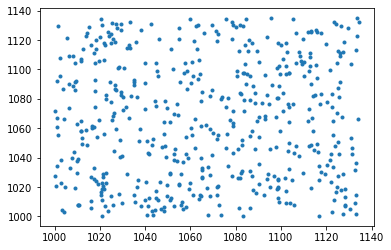

In [3]:
# Check positions of 500 random cells
idxx = numpy.random.choice(nrn_rat.index.values, 500, replace=False)
plt.plot(nrn_rat["ss_flat_x"][idxx], nrn_rat["ss_flat_y"][idxx], '.')

#### 2) load the connectivity 

In this case is data about edges using the function __load_conn_edges__

In [4]:
## RAT
con_fn_rat = "/gpfs/bbp.cscs.ch/project/proj83/circuits/Bio_M/20200805/connectome/structural/edges.sonata"
h5_rat = h5py.File(con_fn_rat, "r")
ranges_rat = h5_rat["edges/default/indices/target_to_source/node_id_to_ranges"][nrn_rat["node_ids"], :]
edge_ids_rat = h5_rat["edges/default/indices/target_to_source/range_to_edge_id"][ranges_rat[:, 0]]

E_rat = lcm.load_conn_edges(h5_rat, edge_ids_rat, 'rat')
E_rat.head()

1025it [00:13, 76.11it/s] 
1025it [00:12, 79.82it/s]


afferent_center_x


1025it [00:03, 295.09it/s]


afferent_center_y


1025it [00:03, 315.92it/s]


afferent_center_z


1025it [00:04, 255.74it/s]


,@target_node,@source_node,afferent_center_x,afferent_center_y,afferent_center_z
0,9259,273,4809.127441,-2889.490234,-2567.126953
1,9259,550,4784.570312,-3034.156250,-2573.226074
2,9259,550,4770.990234,-2902.882812,-2579.571289
3,9259,550,4744.219238,-3012.084717,-2552.827881
4,9259,550,4748.102539,-2942.486572,-2610.850098


#### 3) save flat locations into the dataframe E_rat

Using __save_flat_loc__ 

This could take a while...

In [5]:
xyz = ["afferent_center_x", "afferent_center_y", "afferent_center_z"]

E_rat = lcm.save_flat_loc(E_rat, xyz, fm_rat, orient_rat, pixel_size=pixel_sz_rat)
E_rat

/gpfs/bbp.cscs.ch/home/barros/ConnectomeUtilities/conntility/flatmapping/_supersample_utility.py:137: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  res = Rotation.align_vectors(vtgt, vv)


Rotation errors: min: 0.0, median: 0.09387602600937471, mean: 0.136282418448154, std: 0.15664142313801505, max: 2.0


,@target_node,@source_node,afferent_center_x,afferent_center_y,afferent_center_z,flat_x,depth,flat_y
0,9259,273,4809.127441,-2889.490234,-2567.126953,1134.910348,203.843799,1077.423633
1,9259,550,4784.570312,-3034.156250,-2573.226074,1032.650319,101.200418,994.156695
2,9259,550,4770.990234,-2902.882812,-2579.571289,1118.680422,269.964614,1059.286815
3,9259,550,4744.219238,-3012.084717,-2552.827881,1009.733821,215.039800,1015.327551
4,9259,550,4748.102539,-2942.486572,-2610.850098,1089.069014,218.002858,1022.983582
...,...,...,...,...,...,...,...,...
23196014,3414084,4230499,4617.398926,-2943.237793,-2535.121094,979.917039,346.237338,1022.179987
23196015,3414084,4230571,4818.194336,-2744.489990,-2355.242188,1127.022176,149.848894,1262.403837
23196016,3414084,4230933,4763.271484,-2846.999023,-2405.393066,1059.825973,143.984933,1164.304669
23196017,3414084,4231215,4816.013184,-2775.965088,-2373.527588,1122.202455,134.797912,1235.170858


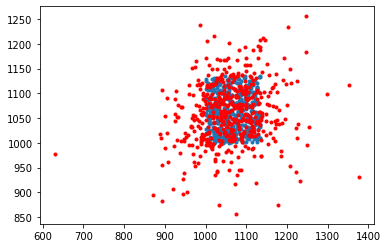

In [6]:
# Sanity check of neuron and synapse location for RAT

idxx = numpy.random.choice(nrn_rat.index.values, 500, replace=False)
plt.plot(nrn_rat["ss_flat_x"][idxx], nrn_rat["ss_flat_y"][idxx], '.')

idxx = numpy.random.choice(E_rat.index, 500, replace=False)
plt.plot(E_rat["flat_x"][idxx], E_rat["flat_y"][idxx], 'r.')

#### 4) Build connectivity object, compress it and save it

Using __build_conn_mat__

In [7]:
M_rat = lcm.build_conn_mat(E_rat, nrn_rat)

# Safe
fname_rat_raw = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Rat_1000nodes_squared_struc_conma.h5"
M_rat.to_h5(fname_rat_raw)

# Compress and safe
fname_rat_raw = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Rat_1000nodes_squared_struc_conmat_compressed.h5"
M_rat_comp = M_rat.compress()
M_rat_comp.to_h5(fname_rat_raw)

In [8]:
# As many of the synapses will be out of the selected range we need to filter them 
# The ConnectivityMatrix object expects the indices of pre- and post-synaptic neurons to be 
# in the range of 0, 1, 2, ..., N, where N is the size of the population. 
# However, in this case we were giving it the gids of the neurons which can be all over the 
# place (0, 5, 20, 25, 100, ....), so we need to re-index

# filter, re-index, compress for faster loading and safe

fname_r_filt = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Rat_1000nodes_squared_struc_conmat_filtered.h5"
M_rat = lcm.filter_and_reindex(M_rat)
M_rat.to_h5(fname_r_filt)

fname_r_comp = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Rat_1000nodes_squared_struc_conmat_filtered_compressed.h5"
M_r_comp = M_rat.compress()
M_r_comp.to_h5(fname_r_comp)

9.88% of the touches are within the volume


## Now we do the same for the Human circuit

#### 1) load the circuit and the positions and orientations of cells in the respective flatmaps

In [9]:
## HUMAN
fn_h = "/gpfs/bbp.cscs.ch/project/proj159/circuit_building/270923/run/sonata/circuit_config.json"
h_atlas_dir = "/gpfs/bbp.cscs.ch/project/proj159/circuit_building/270923/atlas/"

fm_h = voxcell.VoxelData.load_nrrd(h_atlas_dir + "flatmap.nrrd")
orient_h = voxcell.VoxelData.load_nrrd(h_atlas_dir + "orientation.nrrd")
circ_h = snap.Circuit(fn_h)

syn = 'EXC'
layers_h = ['L2','L3a','L3b']
range_x_h = [700, 920] # square space similar to human circuit radius for 1000 nodes
range_y_h = [700,920]
#range_x_h = [700, 1660] # square space similar to human circuit radius for 20000 nodes
#range_y_h = [700,1660]
pixel_sz_h = 16.0
#node_pop_h = "hncx_neurons__hncx_neurons_chemical_synapse"

nrn_h = lcm.load_conn_node(circ_h, layers_h, syn, range_x_h, range_y_h, fm_h, orient_h, pixel_sz_h)
nrn_h

Rotation errors: min: 0.0, median: 0.0, mean: 0.0, std: 0.0, max: 0.0


,population,node_ids,etype,layer,morphology,mtype,synapse_class,x,y,z,ss_flat_x,depth,ss_flat_y
129,hncx_neurons,129,PYR_L23,L2,689309060_-_Scale_x1.000_y1.050_z1.000,L23_PTPC,EXC,359.172340,2126.900717,871.416146,847.172340,481.099283,895.416146
189,hncx_neurons,189,PYR_L23,L2,685814252,L23_PTPC,EXC,391.689524,2316.314653,709.983853,879.689524,291.685347,733.983853
196,hncx_neurons,196,PYR_L23,L2,689360253,L23_PTPC,EXC,214.191847,2168.465053,730.788610,702.191847,439.534947,754.788610
336,hncx_neurons,336,PYR_L23,L2,685814252_-_Scale_x1.000_y1.025_z1.000,L23_PTPC,EXC,293.187345,2103.970435,847.897572,781.187345,504.029565,871.897572
371,hncx_neurons,371,PYR_L23,L2,689312221_-_Scale_x1.000_y1.050_z1.000,L23_PTPC,EXC,411.932284,2255.420079,856.869715,899.932284,352.579921,880.869715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106821,hncx_neurons,106821,PYR_L23,L3b,1067_H38_01_160113_cell2_-_Scale_x1.000_y0.950...,L23_STPC,EXC,247.794416,1391.995860,698.063098,735.794416,1216.004140,722.063098
106867,hncx_neurons,106867,PYR_L23,L3b,0849_H53_03_right,L23_STPC,EXC,412.374930,1612.898298,701.094068,900.374930,995.101702,725.094068
107082,hncx_neurons,107082,PYR_L23,L3b,1067_H38_01_160113_cell2_-_Scale_x1.000_y0.950...,L23_STPC,EXC,383.846584,1500.328865,795.015569,871.846584,1107.671135,819.015569
107223,hncx_neurons,107223,PYR_L23,L3b,1067_H38_01_160113_cell2,L23_STPC,EXC,309.154275,1499.358971,852.393985,797.154275,1108.641029,876.393985


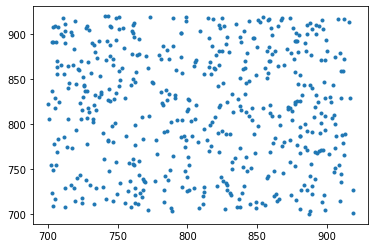

In [10]:
# Check positions of 500 random cells
idxx = numpy.random.choice(nrn_h.index.values, 500, replace=False)
plt.plot(nrn_h["ss_flat_x"][idxx], nrn_h["ss_flat_y"][idxx], '.')

#### 2) load the connectivity 

In [11]:
con_fn_h = "/gpfs/bbp.cscs.ch/project/proj159/circuit_building/270923/run/sonata/networks/edges/structural/hncx_neurons__hncx_neurons_chemical_synapse/edges.h5"
h5_h = h5py.File(con_fn_h, "r")
ranges_h = h5_h["edges/hncx_neurons__hncx_neurons_chemical_synapse/indices/target_to_source/node_id_to_ranges"][nrn_h["node_ids"], :]
edge_ids_h = h5_h["edges/hncx_neurons__hncx_neurons_chemical_synapse/indices/target_to_source/range_to_edge_id"][ranges_h[:, 0]]

E_h = lcm.load_conn_edges(h5_h, edge_ids_h, 'human')
E_h.head()

1022it [00:02, 470.61it/s]
1022it [00:02, 450.26it/s]


afferent_center_x


1022it [00:02, 473.99it/s]


afferent_center_y


1022it [00:02, 451.44it/s]


afferent_center_z


1022it [00:02, 488.17it/s]


,@target_node,@source_node,afferent_center_x,afferent_center_y,afferent_center_z
0,129,133,313.720520,2110.556152,874.406433
1,129,189,367.225952,2226.489502,813.966980
2,129,191,249.366608,2243.337402,898.655518
3,129,196,322.193634,2237.902100,771.184692
4,129,211,287.319000,2376.793945,865.197998


#### 3) save flat locations into the dataframe E_h

In [12]:
xyz = ["afferent_center_x", "afferent_center_y", "afferent_center_z"]

E_h = lcm.save_flat_loc(E_h, xyz, fm_h, orient_h, pixel_size=pixel_sz_h)
E_h

Rotation errors: min: 0.0, median: 0.0, mean: 0.0, std: 0.0, max: 0.0


,@target_node,@source_node,afferent_center_x,afferent_center_y,afferent_center_z,flat_x,depth,flat_y
0,129,133,313.720520,2110.556152,874.406433,801.720520,497.443848,898.406433
1,129,189,367.225952,2226.489502,813.966980,855.225952,381.510498,837.966980
2,129,191,249.366608,2243.337402,898.655518,737.366608,364.662598,922.655518
3,129,196,322.193634,2237.902100,771.184692,810.193634,370.097900,795.184692
4,129,211,287.319000,2376.793945,865.197998,775.319000,231.206055,889.197998
...,...,...,...,...,...,...,...,...
8511401,107458,241344,443.447632,1433.065430,755.448425,931.447632,1174.934570,779.448425
8511402,107458,241344,445.848114,1439.322144,750.967285,933.848114,1168.677856,774.967285
8511403,107458,241360,587.759155,1400.267822,862.829102,1075.759155,1207.732178,886.829102
8511404,107458,241360,587.476868,1400.578979,862.493225,1075.476868,1207.421021,886.493225


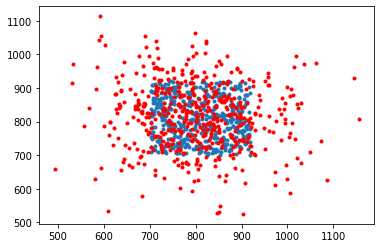

In [13]:
# Sanity check of neuron and synapse location for HUMAN

idxx = numpy.random.choice(nrn_h.index.values, 500, replace=False)
plt.plot(nrn_h["ss_flat_x"][idxx], nrn_h["ss_flat_y"][idxx], '.')

idxx = numpy.random.choice(E_h.index, 500, replace=False)
plt.plot(E_h["flat_x"][idxx], E_h["flat_y"][idxx], 'r.')

#### 4) Build connectivity object, compress it and save it

In [14]:
M_h = lcm.build_conn_mat(E_h, nrn_h)

# Safe
fname_h_raw = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Human_1000nodes_squared_struc_conmat.h5"
M_h.to_h5(fname_h_raw)

# Compress and safe
fname_h_raw = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Human_1000nodes_squared_struc_conmat_compressed.h5"
M_h_comp = M_h.compress()
M_h_comp.to_h5(fname_h_raw)

In [15]:
# As many of the synapses will be out of the selected range we need to filter them 
# The ConnectivityMatrix object expects the indices of pre- and post-synaptic neurons to be 
# in the range of 0, 1, 2, ..., N, where N is the size of the population. 
# However, in this case we were giving it the gids of the neurons which can be all over the 
# place (0, 5, 20, 25, 100, ....), so we need to re-index

# filter, re-index, compress for faster loading and safe

fname_h_filt = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Human_1000nodes_squared_struc_conmat_filtered.h5"
M_h = lcm.filter_and_reindex(M_h)
M_h.to_h5(fname_h_filt)

fname_h_comp = "/gpfs/bbp.cscs.ch/project/proj159/home/barros/conn_matrix/Human_1000nodes_squared_struc_conmat_filtered_compressed.h5"
M_h_comp = M_h.compress()
M_h_comp.to_h5(fname_h_comp)

21.90% of the touches are within the volume
